<a href="https://colab.research.google.com/github/Arati611/ML-Practicals/blob/main/experiment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(2976, 9)
          Time        Date Day of the week  CarCount  BikeCount  BusCount  \
0  12:00:00 AM  10-10-2023         Tuesday        33          3         1   
1  12:15:00 AM  10-10-2023         Tuesday        35          3         2   
2  12:30:00 AM  10-10-2023         Tuesday        33          1         4   
3  12:45:00 AM  10-10-2023         Tuesday        21          3         1   
4  01:00:00 AM  10-10-2023         Tuesday        26          2         0   

   TruckCount  Total Traffic Situation  
0          32     69            normal  
1          32     72            normal  
2          40     78            normal  
3          28     53               low  
4          30     58               low  
Traffic Situation
normal    1306
high       747
low        489
heavy      434
Name: count, dtype: int64
Using file: /content/TrafficDataset.csv
Original Dataset:
          Time        Date Day of the week  CarCount  BikeCount  BusCount  \
0  12:00:00 AM  10-10-2023         Tuesday

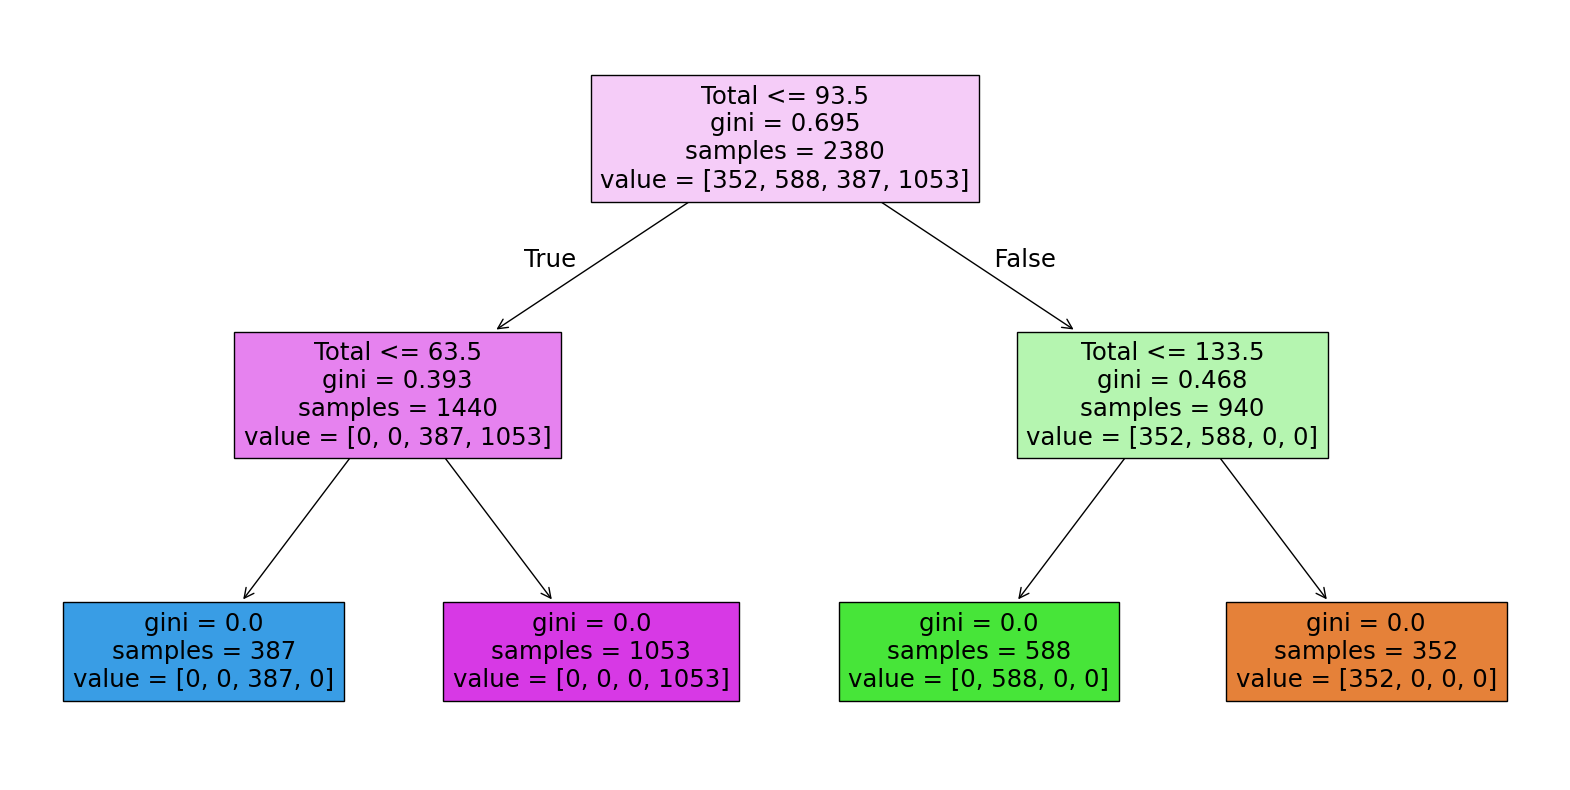

In [8]:
# Create a practice Traffic Dataset
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

# 31 days x 96 readings (every 15 minutes) = 2976 rows
times = pd.date_range("2023-10-10 00:00", periods=2976, freq="15min")
hour = times.hour + times.minute / 60

# Rush hours around 8:30 AM and 5:30 PM, quieter on weekends
rush = (np.exp(-((hour - 8.5) ** 2) / (2 * 1.5 ** 2))
        + np.exp(-((hour - 17.5) ** 2) / (2 * 1.8 ** 2)))
factor = 0.15 + rush
factor = np.where(times.dayofweek >= 5, factor * 0.7, factor)

car = rng.poisson(15 + 90 * factor)
bike = rng.poisson(1 + 8 * factor)
bus = rng.poisson(1 + 6 * factor)
truck = rng.poisson(35 - 15 * factor)
total = car + bike + bus + truck

situation = pd.qcut(total, q=[0, 0.15, 0.60, 0.85, 1],
                    labels=["low", "normal", "high", "heavy"]).astype(str)

df = pd.DataFrame({
    "Time": times.strftime("%I:%M:%S %p"),
    "Date": times.strftime("%d-%m-%Y"),
    "Day of the week": times.day_name(),
    "CarCount": car,
    "BikeCount": bike,
    "BusCount": bus,
    "TruckCount": truck,
    "Total": total,
    "Traffic Situation": situation,
})

df.to_csv("/content/TrafficDataset.csv", index=False)
print(df.shape)
print(df.head())
print(df["Traffic Situation"].value_counts())


# Experiment 8: Traffic Situation using Decision Tree

import glob
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix

# Step 1: Load the data
files = glob.glob("/content/*raffic*.csv")
df = pd.read_csv(files[0])
print("Using file:", files[0])
print("Original Dataset:")
print(df.head())

# Step 2: Make an Hour column, then drop Time and Date
df['Hour'] = pd.to_datetime(df['Time'], format='%I:%M:%S %p').dt.hour
df = df.drop(columns=['Time', 'Date'])

# Step 3: Convert text columns to numbers
le = LabelEncoder()
df['Day of the week'] = le.fit_transform(df['Day of the week'])
df['Traffic Situation'] = le.fit_transform(df['Traffic Situation'])
print(df.head(20))

# Step 4: Inputs (x) and output (y)
x = df.drop(columns=['Traffic Situation'])
y = df['Traffic Situation']

# Step 5: Select the 4 best features
selector = SelectKBest(score_func=f_classif, k=4)
x_selected = selector.fit_transform(x, y)
selected_features = x.columns[selector.get_support()]
print("\nSelected Features:")
print(selected_features)

x_selected = pd.DataFrame(x_selected, columns=selected_features)

# Step 6: Split into training and testing data
x_train, x_test, y_train, y_test = train_test_split(
    x_selected, y, test_size=0.2, random_state=42
)

# Step 7: Train the decision tree
model = DecisionTreeClassifier(criterion='gini', random_state=42)
model.fit(x_train, y_train)

# Step 8: Root node
root_index = model.tree_.feature[0]
print("\nRoot node:")
print(x_selected.columns[root_index])

# Step 9: Predict and check accuracy
y_pred = model.predict(x_test)
print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nConfusion matrix")
print(confusion_matrix(y_test, y_pred))

# Step 10: Draw the tree
plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=selected_features, filled=True, max_depth=3)
plt.show()